# Microprice G1 Analysis

This notebook estimates the first-order microprice adjustment
`G1(I, S) = E[M_{tau1} - M_t | I, S]` from one recorded day using the
existing replay pipeline.

Implementation note:
- the microprice code now lives in the `stats.microprice` package
- `stats.microprice` still re-exports the same public functions, so the notebook import path is unchanged
- the package is split into `features`, `labeling`, and `tables` modules to keep the workflow easier to maintain

Scope:
- strict replay by default
- authoritative inputs are `events + snapshots + diffs`
- level-1 state only
- event-time target: next mid-price change within the same valid segment
- no full Stoikov `Q/R/T/B` matrix model in this notebook


## Reading Guide

If you only skim one section, read this one first.

- `mid_price` is the average of the best bid and best ask.
- `spread` is the distance between the best ask and best bid.
- `level1_imbalance` tells us which side of the book is heavier at the top of the book.
- `tau1` means the first later row in the same valid replay segment where the mid-price changes.
- `G1(I, S)` is the average next mid-price move for state `(imbalance bucket, spread bucket)`.
- `p_up` and `p_down` are the fractions of rows where the next mid move was positive or negative.
- `p_up - p_down` is a direction bias score. It does not measure move size.
- `microprice_1 = mid_price + G1(state)` is a derived first-order proxy, not a recorded exchange value.
- both imbalance buckets and spread buckets are parameters, so the state space can be changed without rewriting the notebook logic.

The notebook is descriptive: it estimates a state-dependent response surface and then checks whether
the result is monotone and stable. It is not a trading strategy and it is not the full Stoikov model.


In [1]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


In [2]:
def find_backtester_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "stats").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the exchange-data-backtester project root")


def resolve_day_dir(project_root: Path, *, exchange: str, symbol: str, day: str) -> Path:
    candidates = [
        project_root.parent / "exchange-data-recorder" / "data" / exchange / symbol / day,
        project_root.parent / "exchange-data-recorder" / "data" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / exchange / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / symbol / day,
        project_root / "data" / exchange / symbol / day,
        project_root / "data" / symbol / day,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "schema.json").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate a recorder day folder for {exchange}/{symbol}/{day}")


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-backtester')

In [3]:
exchange = "binance"
symbol = "BTCUSDC"
days = ["20260223", "20260224", "20260225"]
day_dirs = [resolve_day_dir(PROJECT_ROOT, exchange=exchange, symbol=symbol, day=day) for day in days]
primary_day_dir = day_dirs[0]

# Imbalance buckets can be controlled in two ways:
# - set imbalance_bucket_count to an integer and keep imbalance_bucket_edges = None
# - or set explicit imbalance_bucket_edges such as [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
imbalance_bucket_count = 10
imbalance_bucket_edges = None

# Spread buckets are specified in ticks. The last value is treated as a tail bucket.
# Example: [1, 2, 3] -> 1, 2, 3+
# Example: [1, 2] -> 1, 2+
spread_bucket_values = [1, 2]
top_n_levels_for_features = 1
replay_mode = "skip-segment"
min_obs_per_bucket = 200
event_time_or_recv_time = "recv"
future_move_definition = "next_mid_change"
future_move_k = 1
compare_future_move_ks = [2, 4, 5, 10, 15 ,20, 30, 50]
include_trades = False

assert day_dirs, "Need at least one day_dir"
assert all(day_dir.exists() for day_dir in day_dirs), f"Some day_dirs do not exist: {day_dirs}"
assert top_n_levels_for_features == 1, "The current replay helper only supports top-of-book features"
assert replay_mode in {"strict", "skip-segment"}
assert event_time_or_recv_time in {"recv", "event"}
assert future_move_definition in {"next_mid_change", "kth_mid_change"}
assert int(future_move_k) >= 1
assert all(int(k) >= 1 for k in compare_future_move_ks)
assert imbalance_bucket_count is None or int(imbalance_bucket_count) >= 1
if imbalance_bucket_edges is not None:
    assert len(imbalance_bucket_edges) >= 2, "Need at least two imbalance bucket edges"
    assert list(imbalance_bucket_edges) == sorted(imbalance_bucket_edges), "imbalance_bucket_edges must be sorted"
assert len(spread_bucket_values) >= 1
assert list(spread_bucket_values) == sorted(spread_bucket_values), "spread_bucket_values must be sorted"

resolved_future_move_k = 1 if future_move_definition == "next_mid_change" else int(future_move_k)
target_label = "tau1" if resolved_future_move_k == 1 else f"tau{resolved_future_move_k}"
signal_label = "G1" if resolved_future_move_k == 1 else f"G{resolved_future_move_k}"
comparison_ks = list(dict.fromkeys([resolved_future_move_k] + [int(k) for k in compare_future_move_ks]))

config = {
    "exchange": exchange,
    "symbol": symbol,
    "days": days,
    "day_dirs": [str(day_dir) for day_dir in day_dirs],
    "imbalance_bucket_count": imbalance_bucket_count,
    "imbalance_bucket_edges": imbalance_bucket_edges,
    "spread_bucket_values": spread_bucket_values,
    "top_n_levels_for_features": top_n_levels_for_features,
    "replay_mode": replay_mode,
    "min_obs_per_bucket": min_obs_per_bucket,
    "event_time_or_recv_time": event_time_or_recv_time,
    "future_move_definition": future_move_definition,
    "future_move_k": future_move_k,
    "resolved_future_move_k": resolved_future_move_k,
    "compare_future_move_ks": comparison_ks,
    "include_trades": include_trades,
}
pd.DataFrame({"parameter": list(config.keys()), "value": list(config.values())})


,parameter,value
0,exchange,binance
1,symbol,BTCUSDC
2,days,"[20260223, 20260224, 20260225]"
3,day_dirs,[/Users/hoangdeveloper/PycharmProjects/exchang...
4,imbalance_bucket_count,10
5,imbalance_bucket_edges,None
6,spread_bucket_values,"[1, 2]"
7,top_n_levels_for_features,1
8,replay_mode,skip-segment
9,min_obs_per_bucket,200


## Load And Validate Dataset

The notebook loads multiple `day_dirs` under the dataset contract, summarizes the files that exist for each day,
and reuses the existing replay pipeline instead of rebuilding exchange sync logic. In `strict` mode, a broken replay should fail fast for any selected day.


In [4]:
from stats.io import load_day
from stats.microprice import estimate_g1_tables, get_or_build_pooled_microprice_labeled_table
from stats.notebook import replay_summary

datasets = [load_day(day_dir) for day_dir in day_dirs]
schemas = [json.loads((day_dir / "schema.json").read_text(encoding="utf-8")) for day_dir in day_dirs]

schema_summary_rows = []
manifest_rows = []
validation_rows = []
event_count_rows = []
segment_rows = []

for dataset, schema in zip(datasets, schemas):
    day = dataset.day_dir.name
    events = dataset.load_events()
    validation = replay_summary(dataset, replay_on_gap=replay_mode)

    instrument = schema.get("instrument", {}) if isinstance(schema, dict) else {}
    schema_summary_rows.append(
        {
            "day": day,
            "schema_version": schema.get("schema_version"),
            "created_utc": schema.get("created_utc"),
            "base_asset": instrument.get("base_asset"),
            "quote_asset": instrument.get("quote_asset"),
            "tick_size": instrument.get("tick_size"),
        }
    )
    manifest_rows.append(
        {
            "day": day,
            "schema_path": str(dataset.paths.schema_path),
            "events_path": str(dataset.paths.events_path),
            "gaps_path": str(dataset.paths.gaps_path),
            "trades_path": str(dataset.paths.trades_path),
            "orderbook_ws_depth_path": str(dataset.paths.book_path),
            "diffs_count": len(dataset.paths.diff_paths),
            "snapshot_csv_count": len(dataset.paths.snapshot_csv_paths),
            "snapshot_json_count": len(dataset.paths.snapshot_json_paths),
        }
    )
    validation_rows.append({"day": day, **validation})

    if events is not None and not events.empty:
        event_counts = events["type"].value_counts(dropna=False).rename_axis("event_type").reset_index(name="count")
        event_counts.insert(0, "day", day)
        event_count_rows.append(event_counts)

    for seg in dataset.build_segments():
        segment_rows.append(
            {
                "day": day,
                "segment_index": seg.index,
                "tag": seg.tag,
                "event_id": seg.event_id,
                "recv_seq_start": seg.recv_seq,
                "recv_seq_end": seg.end_recv_seq,
                "epoch_id": seg.epoch_id,
                "snapshot_csv_path": str(seg.snapshot_csv_path),
                "snapshot_json_path": str(seg.snapshot_json_path) if seg.snapshot_json_path is not None else None,
            }
        )

schema_summary = pd.DataFrame(schema_summary_rows).sort_values("day").reset_index(drop=True)
dataset_manifest = pd.DataFrame(manifest_rows).sort_values("day").reset_index(drop=True)
validation_status = pd.DataFrame(validation_rows).sort_values("day").reset_index(drop=True)
event_type_counts = (
    pd.concat(event_count_rows, ignore_index=True).sort_values(["day", "event_type"]).reset_index(drop=True)
    if event_count_rows
    else pd.DataFrame(columns=["day", "event_type", "count"])
)
segments = pd.DataFrame(segment_rows).sort_values(["day", "segment_index"]).reset_index(drop=True)
validation_totals = {
    "days_loaded": int(len(datasets)),
    "segments_total": int(validation_status["segments_total"].sum()),
    "segments_kept": int(validation_status["segments_kept"].sum()),
    "segments_skipped": int(validation_status["segments_skipped"].sum()),
    "replay_on_gap": replay_mode,
}

display(schema_summary)
display(dataset_manifest)
display(validation_status)
display(pd.DataFrame([validation_totals]))
display(event_type_counts)
display(segments)


,day,schema_version,created_utc,base_asset,quote_asset,tick_size
0,20260223,4,2026-02-23T01:00:04.574099+00:00,None,None,None
1,20260224,4,2026-02-24T01:00:04.541620+00:00,None,None,None
2,20260225,4,2026-02-25T01:00:04.424953+00:00,None,None,None


,day,schema_path,events_path,gaps_path,trades_path,orderbook_ws_depth_path,diffs_count,snapshot_csv_count,snapshot_json_count
0,20260223,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,1,1,1
1,20260224,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,1,1,1
2,20260225,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...,1,2,2


,day,replay_on_gap,segments_total,segments_kept,segments_skipped
0,20260223,skip-segment,1,1,0
1,20260224,skip-segment,1,1,0
2,20260225,skip-segment,2,1,1


,days_loaded,segments_total,segments_kept,segments_skipped,replay_on_gap
0,3,4,3,1,skip-segment


,day,event_type,count
0,20260223,run_start,1
1,20260223,run_stop,1
2,20260223,snapshot_loaded,1
3,20260223,snapshot_request,1
4,20260223,state_change,3
5,20260223,window_end,1
6,20260223,ws_connect,1
7,20260223,ws_connecting,1
8,20260223,ws_first_data,1
9,20260223,ws_open,1


,day,segment_index,tag,event_id,recv_seq_start,recv_seq_end,epoch_id,snapshot_csv_path,snapshot_json_path
0,20260223,0,initial,1771808404594,6,NaN,0,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...
1,20260224,0,initial,1771894804559,6,NaN,0,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...
2,20260225,0,initial,1771981204436,6,12.0,0,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...
3,20260225,1,resync_000001,1771981204442,14,NaN,1,/Users/hoangdeveloper/PycharmProjects/exchange...,/Users/hoangdeveloper/PycharmProjects/exchange...


## Replay Order Book

The pooled notebook still replays each day separately. `get_or_build_pooled_microprice_labeled_table(...)` first builds valid day-local replayed states from `events + snapshots + diffs`, then concatenates the labeled rows across days. That keeps replay correctness day-local and only pools after segment-safe reconstruction.


In [5]:
labeled = get_or_build_pooled_microprice_labeled_table(
    day_dirs,
    cache_root=PROJECT_ROOT,
    on_gap=replay_mode,
    event_time_or_recv_time=event_time_or_recv_time,
    imbalance_bucket_count=imbalance_bucket_count,
    imbalance_bucket_edges=imbalance_bucket_edges,
    spread_bucket_values=spread_bucket_values,
    future_move_definition=future_move_definition,
    future_move_k=future_move_k,
).copy()
if labeled.empty:
    raise RuntimeError("Replay produced no valid labeled rows for the selected day set")

required_labeled_cols = [
    "day",
    "recv_seq",
    "event_time_ms",
    "recv_time_ms",
    "epoch_id",
    "segment_index",
    "segment_tag",
    "bid1_price",
    "bid1_qty",
    "ask1_price",
    "ask1_qty",
    "mid_price",
    "spread_abs",
    "spread_ticks",
    "microprice_weighted_mid",
    "analysis_ts",
    "target_mid",
    "tau_k_recv_seq",
    "tau_k_time_ms",
    "time_to_target_ms",
    "delta_mid_target",
    "direction_target",
]
missing = sorted(set(required_labeled_cols) - set(labeled.columns))
if missing:
    raise RuntimeError(f"Missing expected pooled microprice columns: {missing}")

book_states = (
    labeled[
        [
            "day",
            "recv_seq",
            "recv_time_ms",
            "event_time_ms",
            "epoch_id",
            "segment_index",
            "segment_tag",
            "bid1_price",
            "bid1_qty",
            "ask1_price",
            "ask1_qty",
            "mid_price",
            "spread_abs",
            "microprice_weighted_mid",
            "analysis_ts",
        ]
    ]
    .rename(
        columns={
            "mid_price": "mid",
            "spread_abs": "spread",
            "microprice_weighted_mid": "microprice",
            "analysis_ts": "ts",
        }
    )
    .drop_duplicates(subset=["day", "segment_index", "recv_seq"])
    .sort_values(["day", "segment_index", "recv_seq"])
    .reset_index(drop=True)
)
book_states.head()


,day,recv_seq,recv_time_ms,event_time_ms,epoch_id,segment_index,segment_tag,bid1_price,bid1_qty,ask1_price,ask1_qty,mid,spread,microprice,ts
0,20260223,8,1771808404735,1771808404732,0,0,initial,66704.43,0.24012,66704.44,0.18822,66704.435,0.01,66704.435606,2026-02-23 01:00:04.735000+00:00
1,20260223,11,1771808404835,1771808404832,0,0,initial,66704.43,0.24012,66704.44,0.01900,66704.435,0.01,66704.439267,2026-02-23 01:00:04.835000+00:00
2,20260223,12,1771808404935,1771808404932,0,0,initial,66704.43,0.23310,66704.44,0.28342,66704.435,0.01,66704.434513,2026-02-23 01:00:04.935000+00:00
3,20260223,15,1771808405035,1771808405032,0,0,initial,66704.43,0.17070,66704.44,0.37553,66704.435,0.01,66704.433125,2026-02-23 01:00:05.035000+00:00
4,20260223,21,1771808405135,1771808405132,0,0,initial,66701.67,0.00057,66701.68,0.53236,66701.675,0.01,66701.670011,2026-02-23 01:00:05.135000+00:00


## Basic Feature Engineering

This section computes the state variables used in the first-order estimator:
level-1 imbalance, spread in ticks, and a weighted-mid baseline.


In [6]:
features = labeled.copy()

tick_size_summary = (
    features.groupby("day", dropna=False)
    .agg(
        tick_size=("tick_size", "first"),
        rows_after_book_filter=("recv_seq", "size"),
        mid_min=("mid_price", "min"),
        mid_max=("mid_price", "max"),
        spread_ticks_min=("spread_ticks", "min"),
        spread_ticks_max=("spread_ticks", "max"),
        ts_from=("analysis_ts", "min"),
        ts_to=("analysis_ts", "max"),
    )
    .reset_index()
    .sort_values("day")
)

feature_summary = pd.DataFrame(
    {
        "metric": [
            "days_pooled",
            "rows_after_book_filter",
            "mid_min",
            "mid_max",
            "spread_ticks_min",
            "spread_ticks_max",
        ],
        "value": [
            int(features["day"].nunique()),
            int(len(features)),
            float(features["mid_price"].min()),
            float(features["mid_price"].max()),
            int(features["spread_ticks"].min()),
            int(features["spread_ticks"].max()),
        ],
    }
)
display(feature_summary)
display(tick_size_summary)
features.head()


,metric,value
0,days_pooled,3.000
1,rows_after_book_filter,2164695.000
2,mid_min,62510.810
3,mid_max,70015.995
4,spread_ticks_min,1.000
5,spread_ticks_max,5635.000


,day,tick_size,rows_after_book_filter,mid_min,mid_max,spread_ticks_min,spread_ticks_max,ts_from,ts_to
0,20260223,0.01,722786,63874.005,66704.435,1,5635,2026-02-23 01:00:04.735000+00:00,2026-02-23 23:14:45.535000+00:00
1,20260224,0.01,717166,62510.810,64911.985,1,3665,2026-02-24 01:00:04.834000+00:00,2026-02-24 23:14:54.535000+00:00
2,20260225,0.01,724743,64146.635,70015.995,1,5208,2026-02-25 01:00:04.734000+00:00,2026-02-25 23:14:59.234000+00:00


,event_type,recv_seq,recv_time_ms,event_time_ms,epoch_id,segment_index,segment_tag,bid1_price,bid1_qty,ask1_price,...,direction_target,tau_k_analysis_ts,next_mid,tau1_recv_seq,tau1_time_ms,time_to_tau1_ms,delta_mid_tau1,direction_tau1,tau1_analysis_ts,future_move_definition
0,book,8,1771808404735,1771808404732,0,0,initial,66704.43,0.24012,66704.44,...,-1.0,2026-02-23 01:00:05.135000+00:00,66701.675,21.0,1.771808e+12,400.0,-2.76,-1.0,2026-02-23 01:00:05.135000+00:00,next_mid_change
1,book,11,1771808404835,1771808404832,0,0,initial,66704.43,0.24012,66704.44,...,-1.0,2026-02-23 01:00:05.135000+00:00,66701.675,21.0,1.771808e+12,300.0,-2.76,-1.0,2026-02-23 01:00:05.135000+00:00,next_mid_change
2,book,12,1771808404935,1771808404932,0,0,initial,66704.43,0.23310,66704.44,...,-1.0,2026-02-23 01:00:05.135000+00:00,66701.675,21.0,1.771808e+12,200.0,-2.76,-1.0,2026-02-23 01:00:05.135000+00:00,next_mid_change
3,book,15,1771808405035,1771808405032,0,0,initial,66704.43,0.17070,66704.44,...,-1.0,2026-02-23 01:00:05.135000+00:00,66701.675,21.0,1.771808e+12,100.0,-2.76,-1.0,2026-02-23 01:00:05.135000+00:00,next_mid_change
4,book,21,1771808405135,1771808405132,0,0,initial,66701.67,0.00057,66701.68,...,-1.0,2026-02-23 01:00:05.235000+00:00,66698.385,27.0,1.771808e+12,100.0,-3.29,-1.0,2026-02-23 01:00:05.235000+00:00,next_mid_change


## Define State Space

The notebook uses level-1 imbalance buckets and spread regimes in ticks. Both are parameters.
By default the spread regimes are `1`, `2`, and `3+` ticks, but you can change that in the
config cell. For imbalance, you can either choose a bucket count or pass explicit bucket edges.


In [7]:
state_summary = (
    features.groupby(["spread_bucket", "imbalance_bucket"], dropna=False)
    .agg(
        obs_count=("recv_seq", "size"),
        day_count=("day", "nunique"),
        imbalance_mean=("level1_imbalance", "mean"),
        spread_ticks_mean=("spread_ticks", "mean"),
    )
    .reset_index()
    .sort_values(["spread_bucket", "imbalance_bucket"])
)
state_summary.head(20)


,spread_bucket,imbalance_bucket,obs_count,day_count,imbalance_mean,spread_ticks_mean
0,1,1,213153,3,0.021885,1.000000
1,1,2,215846,3,0.129794,1.000000
2,1,3,215955,3,0.249335,1.000000
3,1,4,216013,3,0.363420,1.000000
4,1,5,216042,3,0.464718,1.000000
5,1,6,216136,3,0.559121,1.000000
6,1,7,216050,3,0.660596,1.000000
7,1,8,215961,3,0.769714,1.000000
8,1,9,215836,3,0.879137,1.000000
9,1,10,212975,3,0.976392,1.000000


## Define Target: `tau_k` Mid Change

The notebook now supports a generalized event-time target `tau_k`:
- `tau1` is the first later row in the same valid segment where the mid-price changes
- `tau_k` is the `k`-th later mid-price change in the same valid segment

When `future_move_definition = "next_mid_change"`, the notebook uses `tau1` and estimates the original `G1` surface from the paper.
When `future_move_definition = "kth_mid_change"`, the notebook uses `tau_k` with `future_move_k = k` and estimates the corresponding `G_k` surface.

Why event-time instead of a fixed number of seconds?
- it keeps the target aligned with the actual book evolution
- it avoids mixing quiet periods and active periods
- it lets us ask a simple question: after this book state, what is the next relevant mid-price change in event order?

A row is only labeled if the requested future mid-price change exists inside the same valid replay segment.


In [8]:
target_summary = pd.DataFrame(
    {
        "metric": [
            "days_pooled",
            "target_label",
            "future_move_definition",
            "future_move_k",
            "labeled_rows",
            "p_up_all",
            "p_down_all",
            "mean_delta_mid_target",
            "mean_time_to_target_ms",
            "median_time_to_target_ms",
            "p90_time_to_target_ms",
            "p99_time_to_target_ms",
        ],
        "value": [
            int(labeled["day"].nunique()),
            target_label,
            future_move_definition,
            int(resolved_future_move_k),
            len(labeled),
            float((labeled["direction_target"] > 0).mean()),
            float((labeled["direction_target"] < 0).mean()),
            float(labeled["delta_mid_target"].mean()),
            float(labeled["time_to_target_ms"].mean()),
            float(labeled["time_to_target_ms"].median()),
            float(labeled["time_to_target_ms"].quantile(0.90)),
            float(labeled["time_to_target_ms"].quantile(0.99)),
        ],
    }
)

time_to_target_summary = pd.DataFrame(
    {
        "metric": [
            "mean_ms",
            "std_ms",
            "min_ms",
            "p25_ms",
            "median_ms",
            "p75_ms",
            "p90_ms",
            "p95_ms",
            "p99_ms",
            "max_ms",
        ],
        "value": [
            float(labeled["time_to_target_ms"].mean()),
            float(labeled["time_to_target_ms"].std()),
            float(labeled["time_to_target_ms"].min()),
            float(labeled["time_to_target_ms"].quantile(0.25)),
            float(labeled["time_to_target_ms"].median()),
            float(labeled["time_to_target_ms"].quantile(0.75)),
            float(labeled["time_to_target_ms"].quantile(0.90)),
            float(labeled["time_to_target_ms"].quantile(0.95)),
            float(labeled["time_to_target_ms"].quantile(0.99)),
            float(labeled["time_to_target_ms"].max()),
        ],
    }
)

display(target_summary)
display(time_to_target_summary)
labeled.head()


,metric,value
0,days_pooled,3
1,target_label,tau1
2,future_move_definition,next_mid_change
3,future_move_k,1
4,labeled_rows,2164695
5,p_up_all,0.502389
6,p_down_all,0.497611
7,mean_delta_mid_target,0.026814
8,mean_time_to_target_ms,3112.453792
9,median_time_to_target_ms,1302.0


,metric,value
0,mean_ms,3112.453792
1,std_ms,4956.716772
2,min_ms,3.000000
3,p25_ms,401.000000
4,median_ms,1302.000000
5,p75_ms,3699.000000
6,p90_ms,7999.000000
7,p95_ms,12100.000000
8,p99_ms,24299.000000
9,max_ms,86400.000000


,event_type,recv_seq,recv_time_ms,event_time_ms,epoch_id,segment_index,segment_tag,bid1_price,bid1_qty,ask1_price,...,direction_target,tau_k_analysis_ts,next_mid,tau1_recv_seq,tau1_time_ms,time_to_tau1_ms,delta_mid_tau1,direction_tau1,tau1_analysis_ts,future_move_definition
0,book,8,1771808404735,1771808404732,0,0,initial,66704.43,0.24012,66704.44,...,-1.0,2026-02-23 01:00:05.135000+00:00,66701.675,21.0,1.771808e+12,400.0,-2.76,-1.0,2026-02-23 01:00:05.135000+00:00,next_mid_change
1,book,11,1771808404835,1771808404832,0,0,initial,66704.43,0.24012,66704.44,...,-1.0,2026-02-23 01:00:05.135000+00:00,66701.675,21.0,1.771808e+12,300.0,-2.76,-1.0,2026-02-23 01:00:05.135000+00:00,next_mid_change
2,book,12,1771808404935,1771808404932,0,0,initial,66704.43,0.23310,66704.44,...,-1.0,2026-02-23 01:00:05.135000+00:00,66701.675,21.0,1.771808e+12,200.0,-2.76,-1.0,2026-02-23 01:00:05.135000+00:00,next_mid_change
3,book,15,1771808405035,1771808405032,0,0,initial,66704.43,0.17070,66704.44,...,-1.0,2026-02-23 01:00:05.135000+00:00,66701.675,21.0,1.771808e+12,100.0,-2.76,-1.0,2026-02-23 01:00:05.135000+00:00,next_mid_change
4,book,21,1771808405135,1771808405132,0,0,initial,66701.67,0.00057,66701.68,...,-1.0,2026-02-23 01:00:05.235000+00:00,66698.385,27.0,1.771808e+12,100.0,-3.29,-1.0,2026-02-23 01:00:05.235000+00:00,next_mid_change


## Time To Target Distribution

This section measures how much time typically passes between the current book state and the realized target move.
The timing uses the same clock selected by `event_time_or_recv_time`:
- `recv` means operational latency from the recorder's receive order
- `event` means exchange-event timing when that metadata is available

`time_to_target_ms` is especially useful for judging whether a `G_k` signal is actionable under latency constraints.


,spread_bucket,imbalance_bucket,obs_count,mean_time_to_target_ms,median_time_to_target_ms,p90_time_to_target_ms
0,1,1,213153,1949.499341,600.0,5101.0
1,1,2,215846,2852.519324,1200.0,7300.0
2,1,3,215955,3210.083707,1500.0,8201.0
3,1,4,216013,3589.523381,1701.0,8900.0
4,1,5,216042,3741.120611,1900.0,9204.0
5,1,6,216136,3824.606808,1900.0,9500.0
6,1,7,216050,3595.642347,1799.0,8909.2
7,1,8,215961,3443.758609,1501.0,8601.0
8,1,9,215836,2944.957273,1201.0,7400.0
9,1,10,212975,2091.619918,600.0,5500.0


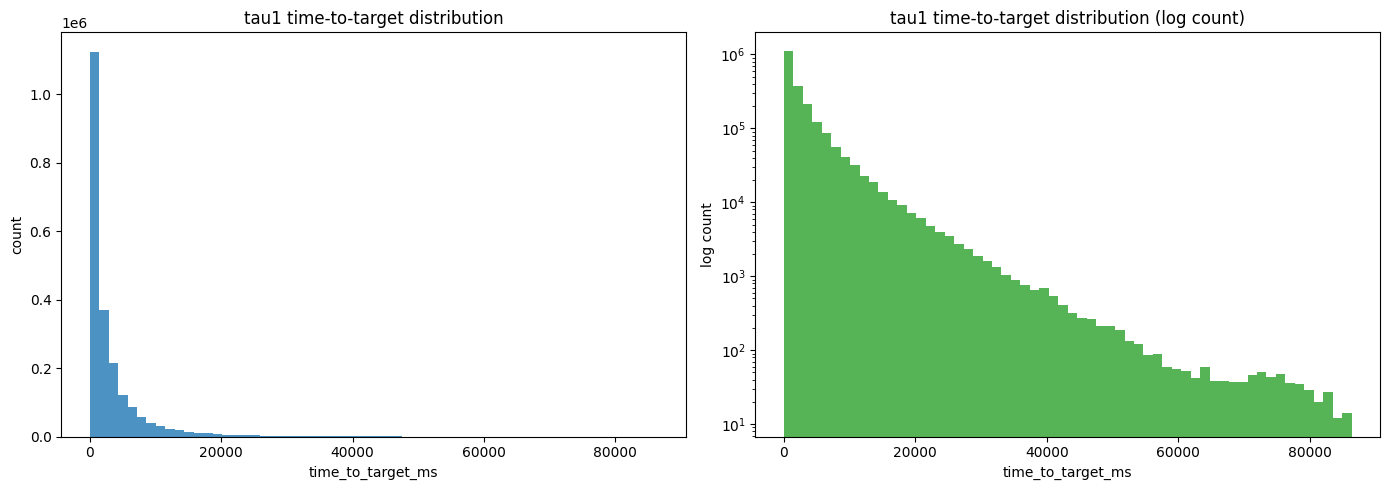

In [9]:
time_to_target_by_state = (
    labeled.groupby(["spread_bucket", "imbalance_bucket"], dropna=False)
    .agg(
        obs_count=("time_to_target_ms", "size"),
        mean_time_to_target_ms=("time_to_target_ms", "mean"),
        median_time_to_target_ms=("time_to_target_ms", "median"),
        p90_time_to_target_ms=("time_to_target_ms", lambda s: float(s.quantile(0.90))),
    )
    .reset_index()
    .sort_values(["spread_bucket", "imbalance_bucket"])
)
display(time_to_target_by_state.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(labeled["time_to_target_ms"], bins=60, color="tab:blue", alpha=0.8)
axes[0].set_title(f"{target_label} time-to-target distribution")
axes[0].set_xlabel("time_to_target_ms")
axes[0].set_ylabel("count")

axes[1].hist(labeled["time_to_target_ms"], bins=60, color="tab:green", alpha=0.8, log=True)
axes[1].set_title(f"{target_label} time-to-target distribution (log count)")
axes[1].set_xlabel("time_to_target_ms")
axes[1].set_ylabel("log count")

fig.tight_layout()


## Estimate `G_k(I, S)`

This is the core estimator of the notebook:
`G_k(I, S) = E[M_{tau_k} - M_t | imbalance_bucket = I, spread_bucket = S]`.

When `k = 1`, this reduces to the original first-order estimator `G1(I, S)`.

How the grouping works:
- every row is assigned an imbalance bucket and a spread bucket
- rows with the same pair `(spread_bucket, imbalance_bucket)` are grouped together
- within each group, we average the realized target move `delta_mid_target`

What the extra columns mean:
- `p_up` is the fraction of rows whose target mid move was positive
- `p_down` is the fraction of rows whose target mid move was negative
- flat moves are counted in neither fraction
- `p_up - p_down` is a simple direction signal: positive means upward moves were more common, negative means downward moves were more common
- `weighted_mid_baseline` is the classic top-of-book weighted midpoint adjustment used as a benchmark, not as the estimator itself

This section is where the notebook turns a table of replayed book states into a state-response surface.


In [10]:
g1_table_long, g1_table_pivot, diagnostics_table = estimate_g1_tables(
    labeled,
    min_obs_per_bucket=min_obs_per_bucket,
)

display(g1_table_long.head(20))
display(g1_table_pivot)


,spread_bucket,imbalance_bucket,g1,p_up,p_down,obs_count,std_delta,weighted_mid_baseline,std_error
0,1,1,-2.399673,0.168874,0.831126,213153,4.803866,-0.004781,0.010405
1,1,2,-1.419604,0.284305,0.715695,215846,5.469538,-0.003702,0.011773
2,1,3,-0.944961,0.353986,0.646014,215955,5.676282,-0.002507,0.012215
3,1,4,-0.507639,0.421539,0.578461,216013,5.858512,-0.001366,0.012605
4,1,5,-0.201960,0.476657,0.523343,216042,5.901438,-0.000353,0.012697
5,1,6,0.216839,0.532294,0.467706,216136,5.866655,0.000591,0.012619
6,1,7,0.638783,0.587123,0.412877,216050,5.845667,0.001606,0.012576
7,1,8,1.056152,0.651826,0.348174,215961,5.690663,0.002697,0.012245
8,1,9,1.485610,0.719959,0.280041,215836,5.247058,0.003791,0.011294
9,1,10,2.338833,0.827355,0.172645,212975,4.926536,0.004764,0.010675


spread_bucket,1,2+
imbalance_bucket,,
1,-2.399673,-3.995849
2,-1.419604,-2.455172
3,-0.944961,-1.271857
4,-0.507639,-0.449453
5,-0.201960,-0.047341
6,0.216839,0.631068
7,0.638783,0.874369
8,1.056152,1.933889
9,1.485610,2.752017


## Visual Diagnostics

The main sanity checks are:
- `G1` should generally increase with imbalance
- the slope should usually be steeper for tighter spreads
- the weighted-mid baseline should be directionally similar but not identical

These plots are for interpretation, not proof. They help answer whether the estimated surface
looks sensible and whether the bucket sizes are large enough to trust the estimates.


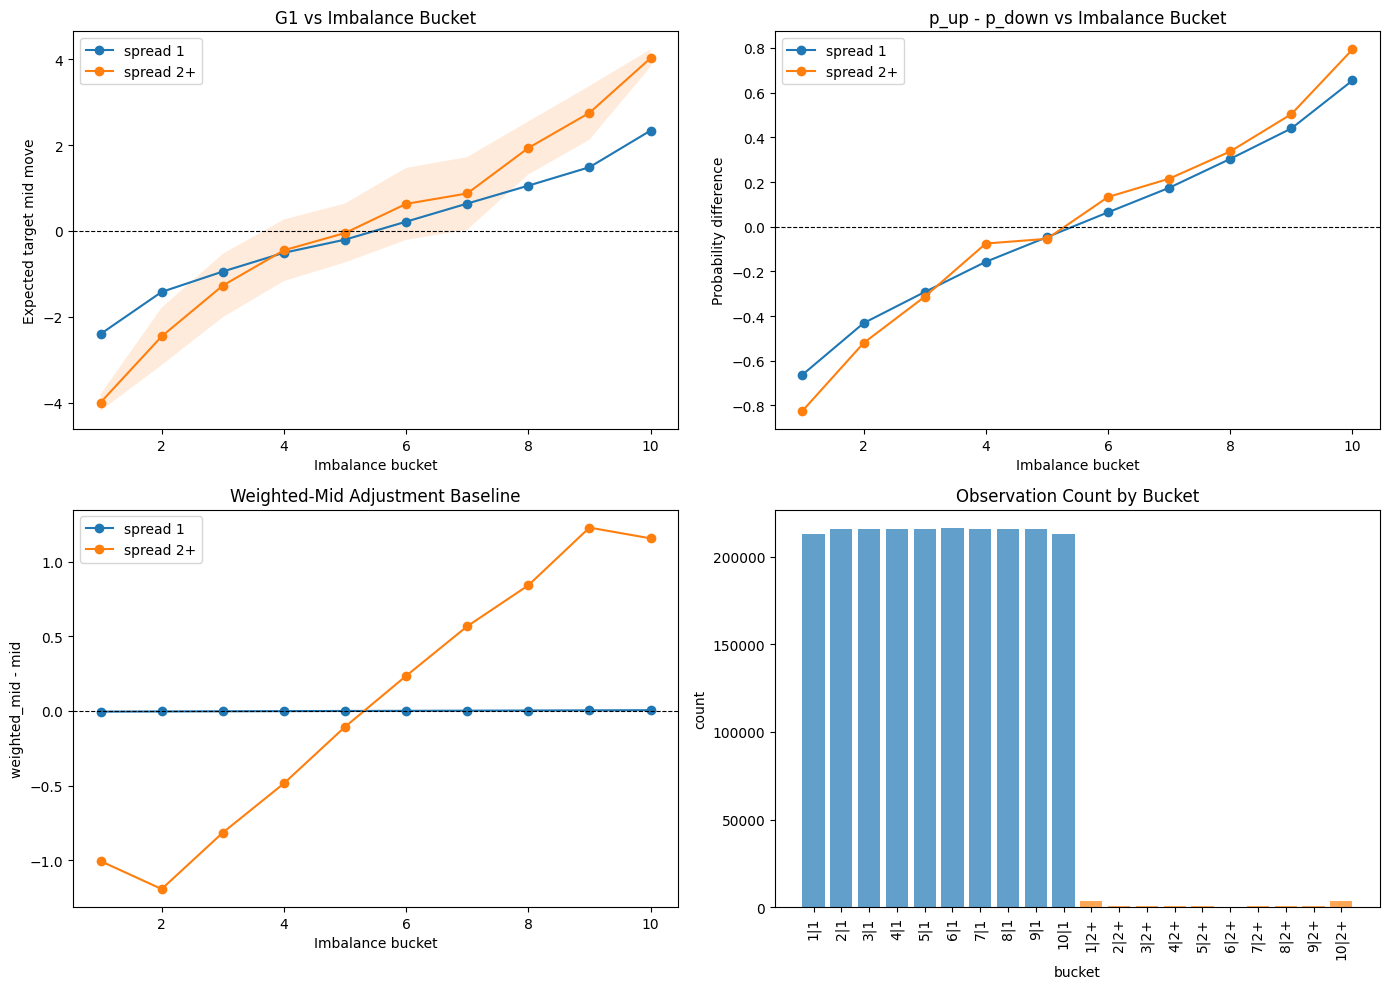

In [11]:
spread_order = list(dict.fromkeys(g1_table_long["spread_bucket"].tolist()))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for spread_bucket in spread_order:
    sub = g1_table_long.loc[g1_table_long["spread_bucket"] == spread_bucket].sort_values("imbalance_bucket")
    if sub.empty:
        continue
    axes[0].plot(sub["imbalance_bucket"], sub["g1"], marker="o", label=f"spread {spread_bucket}")
    axes[0].fill_between(
        sub["imbalance_bucket"],
        sub["g1"] - 1.96 * sub["std_error"],
        sub["g1"] + 1.96 * sub["std_error"],
        alpha=0.15,
    )
    axes[1].plot(sub["imbalance_bucket"], sub["p_up"] - sub["p_down"], marker="o", label=f"spread {spread_bucket}")
    axes[2].plot(sub["imbalance_bucket"], sub["weighted_mid_baseline"], marker="o", label=f"spread {spread_bucket}")
    axes[3].bar(sub["imbalance_bucket"].astype(str) + f"|{spread_bucket}", sub["obs_count"], alpha=0.7)

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title(f"{signal_label} vs Imbalance Bucket")
axes[0].set_xlabel("Imbalance bucket")
axes[0].set_ylabel("Expected target mid move")
axes[0].legend()

axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("p_up - p_down vs Imbalance Bucket")
axes[1].set_xlabel("Imbalance bucket")
axes[1].set_ylabel("Probability difference")
axes[1].legend()

axes[2].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Weighted-Mid Adjustment Baseline")
axes[2].set_xlabel("Imbalance bucket")
axes[2].set_ylabel("weighted_mid - mid")
axes[2].legend()

axes[3].set_title("Observation Count by Bucket")
axes[3].set_xlabel("bucket")
axes[3].set_ylabel("count")
axes[3].tick_params(axis="x", rotation=90)

fig.tight_layout()


## `mid + G_k` Proxy

The notebook maps the estimated state-level surface back onto each row.
- when `k = 1`, `mid + G1(state)` is the first-order microprice proxy used in the original setup
- when `k > 1`, `mid + G_k(state)` is an exploratory event-time projection for the `k`-th future mid change, not the original first-order microprice


In [12]:
state_g1_map = g1_table_long.set_index(["spread_bucket", "imbalance_bucket"])["g1"]
labeled["g1_state"] = [
    state_g1_map.get((spread_bucket, imbalance_bucket), np.nan)
    for spread_bucket, imbalance_bucket in zip(labeled["spread_bucket"], labeled["imbalance_bucket"])
]
labeled["first_order_microprice"] = labeled["mid_price"] + labeled["g1_state"]
labeled["alpha_first_order"] = labeled["first_order_microprice"] - labeled["mid_price"]

proxy_summary = pd.DataFrame(
    {
        "metric": [
            "rows_with_state_g1",
            "alpha_first_order_mean",
            "alpha_first_order_std",
            "weighted_mid_adjustment_mean",
            "corr_alpha_vs_weighted_mid",
        ],
        "value": [
            int(labeled["g1_state"].notna().sum()),
            float(labeled["alpha_first_order"].mean()),
            float(labeled["alpha_first_order"].std()),
            float(labeled["weighted_mid_adjustment"].mean()),
            float(labeled[["alpha_first_order", "weighted_mid_adjustment"]].corr().iloc[0, 1]),
        ],
    }
)
display(proxy_summary)
labeled[[
    "recv_seq",
    "segment_index",
    "mid_price",
    "spread_bucket",
    "imbalance_bucket",
    "g1_state",
    "alpha_first_order",
    "weighted_mid_adjustment",
]].head(20)


,metric,value
0,rows_with_state_g1,2.164695e+06
1,alpha_first_order_mean,2.681382e-02
2,alpha_first_order_std,1.362821e+00
3,weighted_mid_adjustment_mean,4.320622e-04
4,corr_alpha_vs_weighted_mid,1.265650e-01


,recv_seq,segment_index,mid_price,spread_bucket,imbalance_bucket,g1_state,alpha_first_order,weighted_mid_adjustment
0,8,0,66704.435,1,6,0.216839,0.216839,0.000606
1,11,0,66704.435,1,10,2.338833,2.338833,0.004267
2,12,0,66704.435,1,5,-0.201960,-0.201960,-0.000487
3,15,0,66704.435,1,3,-0.944961,-0.944961,-0.001875
4,21,0,66701.675,1,1,-2.399673,-2.399673,-0.004989
5,27,0,66698.385,1,3,-0.944961,-0.944961,-0.002055
6,28,0,66698.385,1,5,-0.201960,-0.201960,-0.000353
7,29,0,66698.385,1,5,-0.201960,-0.201960,-0.000127
8,30,0,66698.385,1,4,-0.507639,-0.507639,-0.001586
9,33,0,66698.015,1,2,-1.419604,-1.419604,-0.003432


## Evaluation

This section reports simple diagnostics for whether the estimated state surface behaves like
a useful first-order microprice signal.

The point here is to check consistency:
- do stronger imbalance buckets generally produce stronger `G1` values?
- does the sign of the estimated surface line up with the realized next move?
- do the results change smoothly rather than jumping around bucket to bucket?

`spearman_bucket_vs_g1` measures monotonicity of the estimated bucket averages themselves.
`spearman_bucket_vs_realized_delta` measures the same ordering idea on the raw labeled rows.
The second number is usually smaller because individual rows are noisier than bucket averages.
`tail_spread` is the range of the estimated `G1` values inside one spread regime.


In [13]:
monotonicity_rows = []
for spread_bucket, sub in g1_table_long.groupby("spread_bucket", sort=False):
    ordered = sub.sort_values("imbalance_bucket")
    monotonicity_rows.append(
        {
            "spread_bucket": spread_bucket,
            "bucket_count": int(len(ordered)),
            "tail_spread": float(ordered["g1"].max() - ordered["g1"].min()),
            "spearman_bucket_vs_g1": float(ordered["imbalance_bucket"].corr(ordered["g1"], method="spearman")),
            "spearman_bucket_vs_realized_delta": float(
                labeled.loc[labeled["spread_bucket"] == spread_bucket, "imbalance_bucket"].corr(
                    labeled.loc[labeled["spread_bucket"] == spread_bucket, "delta_mid_target"],
                    method="spearman",
                )
            ),
        }
    )
evaluation_report = pd.DataFrame(monotonicity_rows)

strongest_signal_row = g1_table_long.iloc[g1_table_long["g1"].abs().argmax()]
strongest_signal = {
    "spread_bucket": str(strongest_signal_row["spread_bucket"]),
    "imbalance_bucket": int(strongest_signal_row["imbalance_bucket"]),
    "g1": float(strongest_signal_row["g1"]),
    "obs_count": int(strongest_signal_row["obs_count"]),
}
summary_report = pd.DataFrame(
    {
        "metric": [
            "days_pooled",
            "target_label",
            "total_valid_rows",
            "total_valid_segments",
            "spread_regimes_used",
            "strongest_signal_bucket",
        ],
        "value": [
            int(labeled["day"].nunique()),
            target_label,
            int(len(labeled)),
            int(validation_status["segments_kept"].sum()),
            ", ".join(sorted(g1_table_long["spread_bucket"].astype(str).unique().tolist())),
            str(strongest_signal),
        ],
    }
)
display(evaluation_report)
display(summary_report)


,spread_bucket,bucket_count,tail_spread,spearman_bucket_vs_g1,spearman_bucket_vs_realized_delta
0,1,10,4.738505,1.0,0.310301
1,2+,10,8.022555,1.0,0.620696


,metric,value
0,days_pooled,3
1,target_label,tau1
2,total_valid_rows,2164695
3,total_valid_segments,3
4,spread_regimes_used,"1, 2+"
5,strongest_signal_bucket,"{'spread_bucket': '2+', 'imbalance_bucket': 10..."


## Compare `k` Horizons

This section compares the immediate `G1` surface with farther event-time targets such as `G2` and `G3`.
The goal is to see whether imbalance is only informative for the next mid change or whether the state signal persists across later mid changes.

Read the comparison like this:
- if `G_k` shrinks quickly as `k` increases, the signal is short-lived
- if `G_k` stays ordered and large for bigger `k`, the signal persists
- if the sign flips for larger `k`, the market may partially mean-revert after the first move


,future_move_k,signal_label,target_label,labeled_rows,spread_regime_count,state_count,mean_abs_g,max_abs_g
0,1,G1,tau1,2164695,2,20,1.482389,4.026706
1,2,G2,tau2,2164669,2,20,1.996029,5.191078
2,4,G4,tau4,2164635,2,20,2.508520,5.917884
3,5,G5,tau5,2164615,2,20,2.652595,6.122692
4,10,G10,tau10,2164409,2,20,2.833226,6.256465
5,15,G15,tau15,2164188,2,20,3.122901,6.425480
6,20,G20,tau20,2163858,2,20,3.054083,7.072414
7,30,G30,tau30,2162709,2,20,3.418266,8.627825
8,50,G50,tau50,2161197,2,20,3.539832,6.941266


,future_move_k,signal_label,spread_bucket,tail_spread,spearman_bucket_vs_g
0,1,G1,1,4.738505,1.000000
1,2,G2,1,7.080226,1.000000
2,4,G4,1,9.321794,1.000000
3,5,G5,1,9.882047,1.000000
4,10,G10,1,10.879469,1.000000
5,15,G15,1,10.882542,1.000000
6,20,G20,1,10.562674,1.000000
7,30,G30,1,9.935043,1.000000
8,50,G50,1,10.716743,1.000000
9,1,G1,2+,8.022555,1.000000


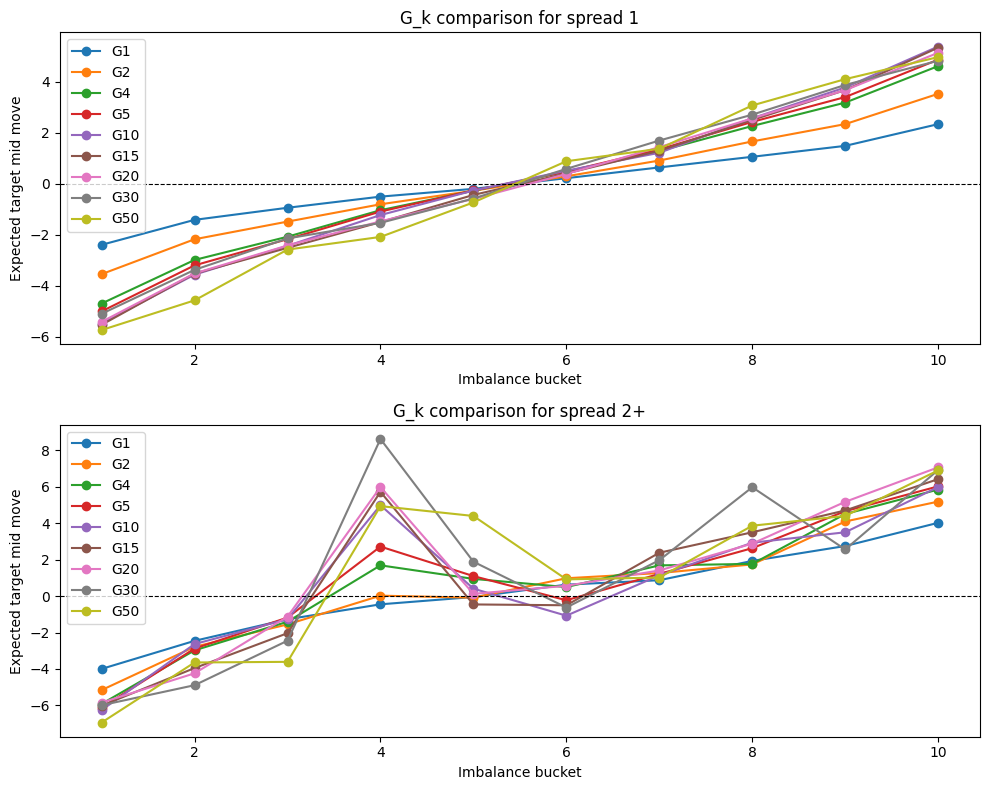

In [14]:
comparison_summary_rows = []
comparison_g1_parts = []
comparison_eval_rows = []

for k in comparison_ks:
    definition = "next_mid_change" if k == 1 else "kth_mid_change"
    labeled_k = get_or_build_pooled_microprice_labeled_table(
        day_dirs,
        cache_root=PROJECT_ROOT,
        on_gap=replay_mode,
        event_time_or_recv_time=event_time_or_recv_time,
        imbalance_bucket_count=imbalance_bucket_count,
        imbalance_bucket_edges=imbalance_bucket_edges,
        spread_bucket_values=spread_bucket_values,
        future_move_definition=definition,
        future_move_k=k,
    )
    g1_long_k, _, _ = estimate_g1_tables(labeled_k, min_obs_per_bucket=min_obs_per_bucket)
    g1_long_k = g1_long_k.copy()
    g1_long_k["future_move_k"] = int(k)
    g1_long_k["signal_label"] = f"G{k}"
    comparison_g1_parts.append(g1_long_k)

    comparison_summary_rows.append(
        {
            "future_move_k": int(k),
            "signal_label": f"G{k}",
            "target_label": "tau1" if k == 1 else f"tau{k}",
            "labeled_rows": int(len(labeled_k)),
            "spread_regime_count": int(g1_long_k["spread_bucket"].nunique()),
            "state_count": int(len(g1_long_k)),
            "mean_abs_g": float(g1_long_k["g1"].abs().mean()),
            "max_abs_g": float(g1_long_k["g1"].abs().max()),
        }
    )

    for spread_bucket, sub in g1_long_k.groupby("spread_bucket", sort=False):
        ordered = sub.sort_values("imbalance_bucket")
        comparison_eval_rows.append(
            {
                "future_move_k": int(k),
                "signal_label": f"G{k}",
                "spread_bucket": spread_bucket,
                "tail_spread": float(ordered["g1"].max() - ordered["g1"].min()),
                "spearman_bucket_vs_g": float(ordered["imbalance_bucket"].corr(ordered["g1"], method="spearman")),
            }
        )

comparison_summary = pd.DataFrame(comparison_summary_rows).sort_values("future_move_k").reset_index(drop=True)
comparison_g1 = pd.concat(comparison_g1_parts, ignore_index=True).sort_values(["spread_bucket", "future_move_k", "imbalance_bucket"])
comparison_eval = pd.DataFrame(comparison_eval_rows).sort_values(["spread_bucket", "future_move_k"]).reset_index(drop=True)

display(comparison_summary)
display(comparison_eval)

spread_order_compare = sorted(comparison_g1["spread_bucket"].astype(str).unique().tolist())
fig, axes = plt.subplots(len(spread_order_compare), 1, figsize=(10, 4 * max(1, len(spread_order_compare))), squeeze=False)
axes = axes.ravel()

for ax, spread_bucket in zip(axes, spread_order_compare):
    sub = comparison_g1.loc[comparison_g1["spread_bucket"].astype(str) == spread_bucket]
    for k in sorted(sub["future_move_k"].unique().tolist()):
        line = sub.loc[sub["future_move_k"] == k].sort_values("imbalance_bucket")
        ax.plot(line["imbalance_bucket"], line["g1"], marker="o", label=f"G{k}")
    ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"G_k comparison for spread {spread_bucket}")
    ax.set_xlabel("Imbalance bucket")
    ax.set_ylabel("Expected target mid move")
    ax.legend()

fig.tight_layout()


## Optional Persistence

This notebook intentionally focuses on the analysis path first. The code base now supports two
persistence levels for reruns:
- per-day labeled microprice rows cached under each `day_dir/cache/...`
- pooled multi-day labeled rows cached under `analysis_cache/...`

The reusable helpers are:
- `stats.get_or_build_microprice_labeled_table(...)`
- `stats.get_or_build_pooled_microprice_labeled_table(...)`
- `stats.estimate_g1_tables(...)`
